In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "../data/ai4i2020.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
df = df.rename(columns={
    "Air temperature [K]": "air_temperature",
    "Process temperature [K]": "process_temperature",
    "Rotational speed [rpm]": "rotational_speed",
    "Torque [Nm]": "torque",
    "Tool wear [min]": "tool_wear",
    "Machine failure": "machine_failure"
})

print(df.columns.tolist())

['UDI', 'Product ID', 'Type', 'air_temperature', 'process_temperature', 'rotational_speed', 'torque', 'tool_wear', 'machine_failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [3]:
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nFailure distribution:")
print(df["machine_failure"].value_counts())

Shape: (10000, 14)

Missing values:
UDI                    0
Product ID             0
Type                   0
air_temperature        0
process_temperature    0
rotational_speed       0
torque                 0
tool_wear              0
machine_failure        0
TWF                    0
HDF                    0
PWF                    0
OSF                    0
RNF                    0
dtype: int64

Failure distribution:
machine_failure
0    9661
1     339
Name: count, dtype: int64


In [4]:
total_records = len(df)

failures = df["machine_failure"].sum()

non_failures = total_records - failures

P_failure = failures / total_records
P_no_failure = non_failures / total_records

print(f"Total records       : {total_records}")
print(f"Failures            : {failures}")
print(f"Non-failures        : {non_failures}")

print(f"\nP(Failure)          : {P_failure:.4f}")
print(f"P(No Failure)       : {P_no_failure:.4f}")

Total records       : 10000
Failures            : 339
Non-failures        : 9661

P(Failure)          : 0.0339
P(No Failure)       : 0.9661


In [5]:
temperature_threshold = df["air_temperature"].quantile(0.75)

print(
    f"High-temperature threshold: "
    f"{temperature_threshold:.2f} K"
)

High-temperature threshold: 301.50 K


In [6]:
df["high_temperature"] = (
    df["air_temperature"] >= temperature_threshold
)

print(
    "High-temperature observations:",
    df["high_temperature"].sum()
)

High-temperature observations: 2592


In [7]:
F = df["machine_failure"] == 1

In [8]:
H = df["high_temperature"]

In [9]:
P_F = F.mean()

print("P(Failure):", P_F)

P(Failure): 0.0339


In [10]:
P_H_given_F = H[F].mean()

print(
    "P(High Temperature | Failure):",
    P_H_given_F
)

P(High Temperature | Failure): 0.5162241887905604


In [11]:
P_H = H.mean()

print(
    "P(High Temperature):",
    P_H
)

P(High Temperature): 0.2592


In [12]:
P_F_given_H = (
    P_H_given_F * P_F
) / P_H

print(
    f"P(Failure | High Temperature): "
    f"{P_F_given_H:.4f}"
)

print(
    f"Posterior Failure Risk: "
    f"{P_F_given_H:.2%}"
)

P(Failure | High Temperature): 0.0675
Posterior Failure Risk: 6.75%


In [13]:
high_temperature_records = H.sum()

high_temperature_failures = (
    H & F
).sum()

direct_probability = (
    high_temperature_failures /
    high_temperature_records
)

print(
    "High-temperature records:",
    high_temperature_records
)

print(
    "High-temperature failures:",
    high_temperature_failures
)

print(
    f"\nDirect probability: "
    f"{direct_probability:.6f}"
)

print(
    f"Bayes probability: "
    f"{P_F_given_H:.6f}"
)

High-temperature records: 2592
High-temperature failures: 175

Direct probability: 0.067515
Bayes probability: 0.067515


In [14]:
print(
    f"Prior failure risk: "
    f"{P_F:.2%}"
)

print(
    f"Failure risk given high temperature: "
    f"{P_F_given_H:.2%}"
)

Prior failure risk: 3.39%
Failure risk given high temperature: 6.75%


In [15]:
risk_multiplier = P_F_given_H / P_F

print(
    f"Risk multiplier: "
    f"{risk_multiplier:.2f}x"
)

Risk multiplier: 1.99x


In [16]:
conditions = {
    "High Air Temperature":
        df["air_temperature"] >= df["air_temperature"].quantile(0.75),

    "High Process Temperature":
        df["process_temperature"] >= df["process_temperature"].quantile(0.75),

    "High Torque":
        df["torque"] >= df["torque"].quantile(0.75),

    "High Tool Wear":
        df["tool_wear"] >= df["tool_wear"].quantile(0.75),

    "Low Rotational Speed":
        df["rotational_speed"] <= df["rotational_speed"].quantile(0.25)
}

In [17]:
results = []

P_failure = df["machine_failure"].mean()

for condition_name, condition in conditions.items():

    P_condition = condition.mean()

    P_condition_given_failure = (
        condition[F].mean()
    )

    P_failure_given_condition = (
        P_condition_given_failure *
        P_failure
    ) / P_condition

    risk_multiplier = (
        P_failure_given_condition /
        P_failure
    )

    results.append({
        "Condition": condition_name,
        "P(Condition)": P_condition,
        "P(Condition | Failure)": P_condition_given_failure,
        "P(Failure | Condition)": P_failure_given_condition,
        "Risk Multiplier": risk_multiplier
    })

bayes_results = pd.DataFrame(results)

bayes_results = bayes_results.sort_values(
    "P(Failure | Condition)",
    ascending=False
)

display(bayes_results)

,Condition,P(Condition),P(Condition | Failure),P(Failure | Condition),Risk Multiplier
4,Low Rotational Speed,0.2513,0.752212,0.101472,2.993284
2,High Torque,0.2501,0.722714,0.097961,2.889700
3,High Tool Wear,0.2543,0.510324,0.068030,2.006781
0,High Air Temperature,0.2592,0.516224,0.067515,1.991606
1,High Process Temperature,0.2518,0.280236,0.037728,1.112931


In [18]:
display(
    bayes_results.style.format({
        "P(Condition)": "{:.2%}",
        "P(Condition | Failure)": "{:.2%}",
        "P(Failure | Condition)": "{:.2%}",
        "Risk Multiplier": "{:.2f}x"
    })
)

,Condition,P(Condition),P(Condition | Failure),P(Failure | Condition),Risk Multiplier
4,Low Rotational Speed,25.13%,75.22%,10.15%,2.99x
2,High Torque,25.01%,72.27%,9.80%,2.89x
3,High Tool Wear,25.43%,51.03%,6.80%,2.01x
0,High Air Temperature,25.92%,51.62%,6.75%,1.99x
1,High Process Temperature,25.18%,28.02%,3.77%,1.11x


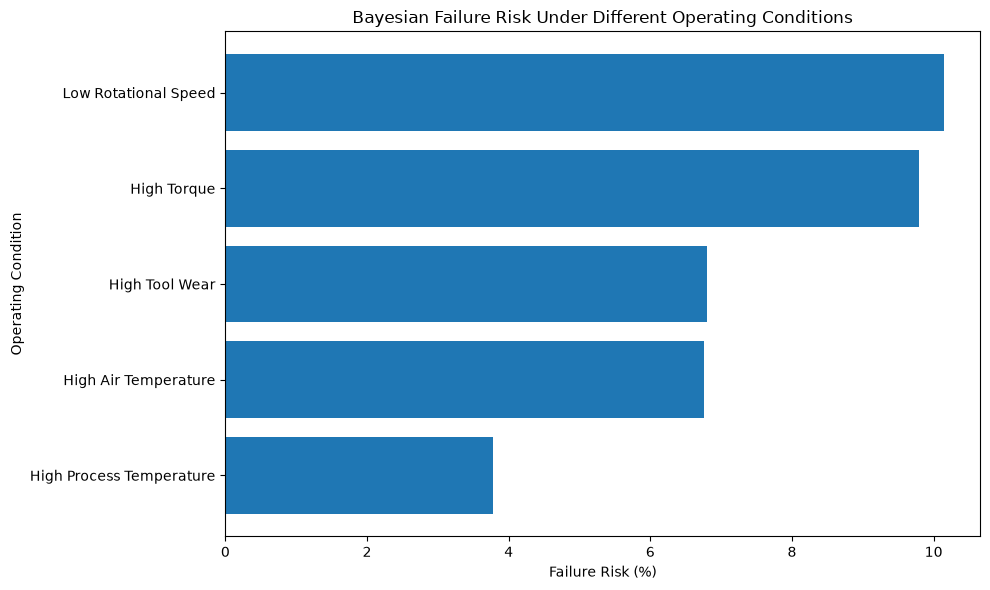

In [19]:
plot_data = bayes_results.sort_values(
    "P(Failure | Condition)"
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["Condition"],
    plot_data["P(Failure | Condition)"] * 100
)

plt.xlabel("Failure Risk (%)")
plt.ylabel("Operating Condition")

plt.title(
    "Bayesian Failure Risk Under Different Operating Conditions"
)

plt.tight_layout()

plt.show()

In [20]:
def bayes_failure_risk(
    dataframe,
    condition_mask,
    target_column="machine_failure"
):

    target = dataframe[target_column].astype(bool)

    condition = pd.Series(
        condition_mask,
        index=dataframe.index
    ).astype(bool)

    P_failure = target.mean()

    P_condition = condition.mean()

    if P_condition == 0:
        raise ValueError(
            "Condition does not occur in the dataset."
        )

    P_condition_given_failure = (
        condition[target].mean()
    )

    posterior = (
        P_condition_given_failure *
        P_failure
    ) / P_condition

    risk_multiplier = (
        posterior / P_failure
    )

    return {
        "prior_failure": P_failure,
        "condition_probability": P_condition,
        "condition_given_failure": P_condition_given_failure,
        "posterior_failure_risk": posterior,
        "risk_multiplier": risk_multiplier
    }

In [21]:
result = bayes_failure_risk(
    df,
    df["air_temperature"] >= temperature_threshold
)

result

{'prior_failure': np.float64(0.0339),
 'condition_probability': np.float64(0.2592),
 'condition_given_failure': np.float64(0.5162241887905604),
 'posterior_failure_risk': np.float64(0.06751543209876543),
 'risk_multiplier': np.float64(1.9916056666302486)}

In [22]:
def interpret_bayesian_risk(
    posterior_risk,
    prior_risk
):

    multiplier = posterior_risk / prior_risk

    if multiplier >= 2:
        return "Strongly elevated risk"

    elif multiplier >= 1.25:
        return "Elevated risk"

    elif multiplier <= 0.75:
        return "Reduced risk"

    else:
        return "Near baseline risk"

In [23]:
interpretation = interpret_bayesian_risk(
    result["posterior_failure_risk"],
    result["prior_failure"]
)

print("Bayesian Interpretation:")
print(interpretation)

Bayesian Interpretation:
Elevated risk


In [24]:
print("=" * 60)
print("UNIT 1 — BAYESIAN FAILURE RISK ANALYSIS")
print("=" * 60)

print(
    f"Baseline Failure Risk       : "
    f"{result['prior_failure']:.2%}"
)

print(
    f"Observed Condition          : "
    f"High Air Temperature"
)

print(
    f"Posterior Failure Risk      : "
    f"{result['posterior_failure_risk']:.2%}"
)

print(
    f"Risk Multiplier             : "
    f"{result['risk_multiplier']:.2f}x"
)

print(
    f"Interpretation              : "
    f"{interpretation}"
)

print("=" * 60)

UNIT 1 — BAYESIAN FAILURE RISK ANALYSIS
Baseline Failure Risk       : 3.39%
Observed Condition          : High Air Temperature
Posterior Failure Risk      : 6.75%
Risk Multiplier             : 1.99x
Interpretation              : Elevated risk
